# CODTECH Internship — Task 2
# Sentiment Analysis with NLP

**Objective:** Perform sentiment analysis on a dataset of reviews using **TF-IDF vectorization** and **Logistic Regression**, showcasing the full pipeline: preprocessing → modeling → evaluation.

**Dataset:** NLTK's **`movie_reviews`** corpus — 2,000 real reviews labelled **positive** / **negative** (1,000 each). It downloads automatically and is a standard benchmark for binary sentiment. The exact same pipeline works on any customer-review CSV (see the note at the end).

**Deliverable checklist**
- [x] Load & inspect the review data
- [x] Text preprocessing (cleaning, stop-word removal)
- [x] TF-IDF vectorization
- [x] Logistic Regression classifier
- [x] Sentiment evaluation (accuracy, report, confusion matrix, ROC-AUC)
- [x] Most-informative words + live predictions

*Author: CODTECH ML Internship submission*

In [1]:
# ---- Imports ----
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import movie_reviews, stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries imported.")

Libraries imported.


## 1. Load the dataset

In [2]:
# Download the corpora (runs once, then cached locally)
nltk.download("movie_reviews", quiet=True)
nltk.download("stopwords", quiet=True)

# Build a DataFrame of (review_text, label)
records = []
for label in movie_reviews.categories():          # 'pos' / 'neg'
    for fid in movie_reviews.fileids(label):
        records.append({"review": movie_reviews.raw(fid), "sentiment": label})

data = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print("Total reviews:", len(data))
print(data["sentiment"].value_counts())
data.head(3)

Total reviews: 2000
sentiment
pos    1000
neg    1000
Name: count, dtype: int64


,review,sentiment
0,the verdict : spine-chilling drama from horror...,pos
1,""" the 44 caliber killer has struck again . "" ...",neg
2,in the company of men made a splash at the sun...,pos


In [3]:
# Peek at one raw review
print(data.loc[0, "sentiment"].upper(), "review (first 400 chars):\n")
print(data.loc[0, "review"][:400], "...")

POS review (first 400 chars):

the verdict : spine-chilling drama from horror maestro stephen king , featuring an outstanding , oscar-winning performance from kathy bates . 
geez , french and saunders had a field day when they set to work on parodying this ! 
sorry , non-british readers may not be familiar with french and saunders - my apologies . 
the pair are british comediennes ( jennifer saunders later went on to become edi ...


## 2. Text preprocessing

We lower-case the text, strip out punctuation / numbers / short tokens, and remove common English stop-words. TF-IDF handles the rest of the weighting.

In [4]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # keep letters only
    tokens = [w for w in text.split()
              if w not in stop_words and len(w) > 2]  # drop stop-words & tiny tokens
    return " ".join(tokens)

data["clean_review"] = data["review"].apply(clean_text)

# Before vs after
print("BEFORE:", data.loc[0, "review"][:120].replace("\n", " "))
print("\nAFTER :", data.loc[0, "clean_review"][:120])

BEFORE: the verdict : spine-chilling drama from horror maestro stephen king , featuring an outstanding , oscar-winning performan

AFTER : verdict spine chilling drama horror maestro stephen king featuring outstanding oscar winning performance kathy bates gee


In [5]:
# Encode labels: positive = 1, negative = 0
data["label"] = (data["sentiment"] == "pos").astype(int)
data[["sentiment", "label"]].value_counts()

sentiment  label
pos        1        1000
neg        0        1000
Name: count, dtype: int64

## 3. Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_review"], data["label"],
    test_size=0.2, random_state=42, stratify=data["label"])

print(f"Train reviews: {len(X_train)}  |  Test reviews: {len(X_test)}")

Train reviews: 1600  |  Test reviews: 400


## 4. TF-IDF vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) turns each review into a weighted word-frequency vector: words that are frequent in a review but rare across the corpus get the highest weight. We include unigrams **and** bigrams and cap the vocabulary at 5,000 features.

In [7]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),     # unigrams + bigrams
    max_features=5000,
    min_df=5,               # ignore very rare terms
    sublinear_tf=True)

X_train_vec = tfidf.fit_transform(X_train)   # fit ONLY on training data
X_test_vec  = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_vec.shape)
print("Example vocabulary terms:", tfidf.get_feature_names_out()[500:508])

TF-IDF matrix shape (train): (1600, 5000)
Example vocabulary terms: ['break' 'breakdown' 'breaking' 'breaks' 'breasts' 'breath' 'breathtaking'
 'brian']


## 5. Train the Logistic Regression model

In [8]:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_vec, y_train)
print("Model trained on", X_train_vec.shape[0], "reviews.")

Model trained on 1600 reviews.


## 6. Sentiment evaluation

In [9]:
y_pred  = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test accuracy : {acc:.3f}")
print(f"ROC-AUC       : {auc:.3f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

Test accuracy : 0.850
ROC-AUC       : 0.929

Classification report:
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85       200
    positive       0.86      0.84      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



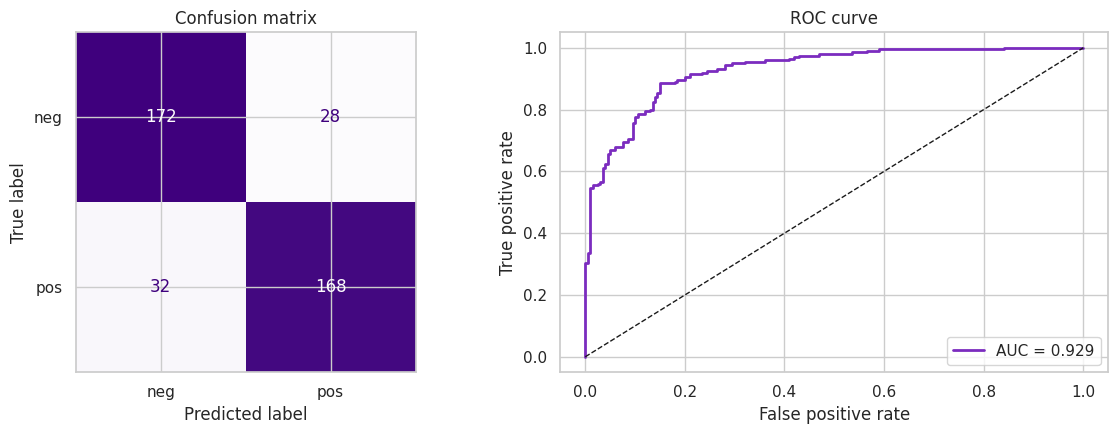

In [10]:
# Confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["neg", "pos"]).plot(
    ax=axes[0], cmap="Purples", colorbar=False)
axes[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#7b2cbf", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve"); axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 7. Which words drive the sentiment?

Logistic Regression coefficients are directly interpretable: the largest positive coefficients push a review toward **positive**, the most negative toward **negative**.

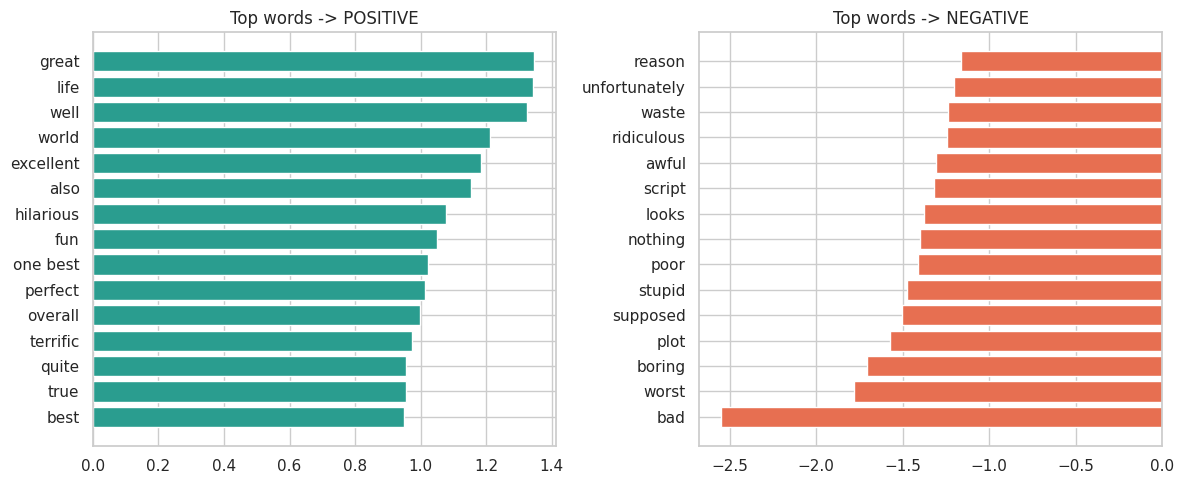

In [11]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]

top_pos = np.argsort(coefs)[-15:]
top_neg = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(feature_names[top_pos], coefs[top_pos], color="#2a9d8f")
axes[0].set_title("Top words -> POSITIVE")
axes[1].barh(feature_names[top_neg], coefs[top_neg], color="#e76f51")
axes[1].set_title("Top words -> NEGATIVE")
plt.tight_layout()
plt.show()

## 8. Try it on new reviews

In [12]:
def predict_sentiment(text):
    vec = tfidf.transform([clean_text(text)])
    prob = clf.predict_proba(vec)[0, 1]
    label = "POSITIVE" if prob >= 0.5 else "NEGATIVE"
    return label, prob

samples = [
    "An absolute masterpiece — brilliant acting and a gripping story from start to finish.",
    "Boring, predictable and way too long. I nearly fell asleep.",
    "The visuals were stunning but the plot made no sense and the ending was disappointing.",
    "One of the best films I have seen this year. Highly recommended!",
]

for s in samples:
    label, prob = predict_sentiment(s)
    print(f"[{label}  p={prob:.2f}]  {s}")

[POSITIVE  p=0.59]  An absolute masterpiece — brilliant acting and a gripping story from start to finish.
[NEGATIVE  p=0.23]  Boring, predictable and way too long. I nearly fell asleep.
[NEGATIVE  p=0.47]  The visuals were stunning but the plot made no sense and the ending was disappointing.
[POSITIVE  p=0.81]  One of the best films I have seen this year. Highly recommended!


## 9. Conclusion & analysis

- A simple **TF-IDF + Logistic Regression** pipeline classifies review sentiment with **strong accuracy and ROC-AUC** on the held-out test set — a great, fast baseline for NLP sentiment tasks.
- The most-informative words are intuitive (praise words → positive, criticism words → negative), confirming the model learned meaningful signal rather than noise.
- Including **bigrams** lets the model capture short phrases (e.g. negations) that single words miss.
- **Possible improvements:** lemmatization, handling negation explicitly, trying `LinearSVC`/`ComplementNB`, or fine-tuning a transformer (e.g. DistilBERT) for higher accuracy.

**Reusing on your own customer reviews (CSV):**
```python
data = pd.read_csv("reviews.csv")            # columns: review_text, sentiment
data = data.rename(columns={"review_text": "review"})
data["label"] = (data["sentiment"] == "positive").astype(int)
# ...then run cells 2 onward unchanged.
```